In [1]:
%run ./00_setup.ipynb
leases = pd.read_parquet(INTERIM_DIR / "leases.parquet")

listings      1,061 rows  29 columns
leases        4,302 rows  35 columns
concessions   3,560 rows  18 columns
asking        3,857 rows  14 columns
Columns dropped from leases: ['available_date', 'property_type', 'furnishing', 'smoking', 'cats_allowed', 'dogs_allowed']
leases: 4,302 rows, 33 columns


## 3. Mix effect: why the yearly median misleads

### 3.1 The naive approach
This is what you'd do without looking too closely: take the median contract rent of all leases signed each year, and its yearly change.

In [2]:
analysis_leases = leases[leases.lease_year.between(FIRST_ANALYSIS_YEAR, DATA_CUTOFF.year)]
naive_yearly = (analysis_leases.groupby("lease_year")
                .agg(leases=("rent_contract", "size"), median_rent=("rent_contract", "median")))
naive_yearly["naive_growth"] = naive_yearly.median_rent.pct_change()
naive_yearly.assign(naive_growth_pct=(naive_yearly.naive_growth * PCT).round(2)).drop(columns="naive_growth")

,leases,median_rent,naive_growth_pct
lease_year,,,
2018,172,1610.0,NaN
2019,328,1730.0,7.45
2020,373,1775.0,2.60
2021,361,1850.0,4.23
2022,422,1912.5,3.38
2023,693,2120.0,10.85
2024,902,2215.0,4.48
2025,958,2305.0,4.06


### 3.2 What changes under the median
So what's moving under that median? For each year: the median floor area, the share of units with 2+ bedrooms, the number of buildings and the rent per sq ft.

In [3]:
mix_yearly = analysis_leases.groupby("lease_year").agg(
    leases=("rent_contract", "size"),
    buildings=("building", "nunique"),
    median_sqft=("sqft", "median"),
    share_2bed_plus=("bedrooms", lambda s: (s >= LARGE_UNIT_MIN_BEDROOMS).mean()),
    median_rent_per_sqft=("rent_contract", lambda s: (s / analysis_leases.loc[s.index, "sqft"]).median()),
)
mix_yearly.assign(share_2bed_plus_pct=(mix_yearly.share_2bed_plus * PCT).round(1)).drop(columns="share_2bed_plus").round(2)

,leases,buildings,median_sqft,median_rent_per_sqft,share_2bed_plus_pct
lease_year,,,,,
2018,172,2,1170.0,1.43,79.7
2019,328,3,1177.5,1.48,78.7
2020,373,3,1180.0,1.53,77.7
2021,361,3,1175.0,1.60,78.4
2022,422,3,1160.0,1.71,72.5
2023,693,5,1095.0,2.04,62.6
2024,902,6,1045.0,2.20,62.2
2025,958,6,1025.0,2.33,60.2


### 3.3 Chart: the portfolio mix changes in 2023–2024

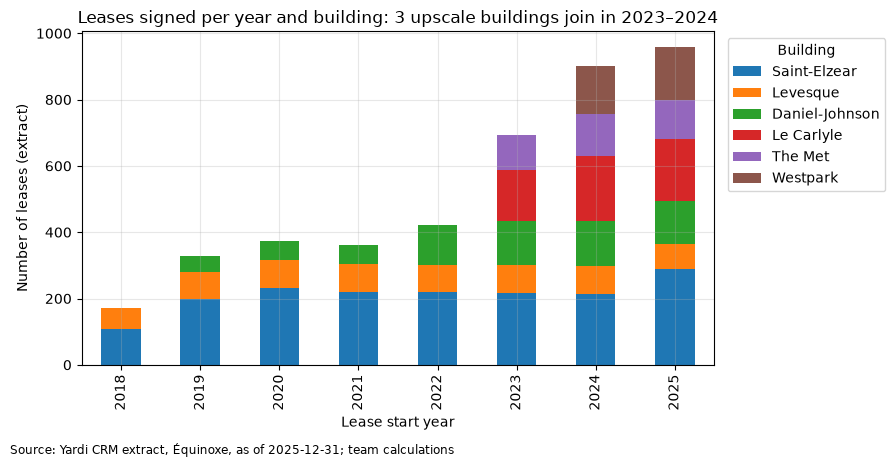

In [4]:
leases_by_building = analysis_leases.pivot_table(index="lease_year", columns="building",
                                                 values="unit_id", aggfunc="size", fill_value=0)
building_order = analysis_leases.groupby("building").lease_year.min().sort_values().index
fig, ax = plt.subplots(figsize=FIGSIZE)
leases_by_building[building_order].plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Leases signed per year and building: 3 upscale buildings join in 2023–2024")
ax.set_xlabel("Lease start year")
ax.set_ylabel("Number of leases (extract)")
ax.legend(title="Building", bbox_to_anchor=(1.01, 1), loc="upper left")
add_source(fig)
plt.tight_layout()
plt.show()

### 3.4 Neutralising the building mix
A first fix: compute the change in the median **within each building**, then average it, weighted by the building's
number of leases (only buildings present in both years). This is a first correction; the full method (same apartment) comes in §4.
If the per-building change comes out much smaller than the naive one, then it's new buildings arriving, not prices, that push the median up.

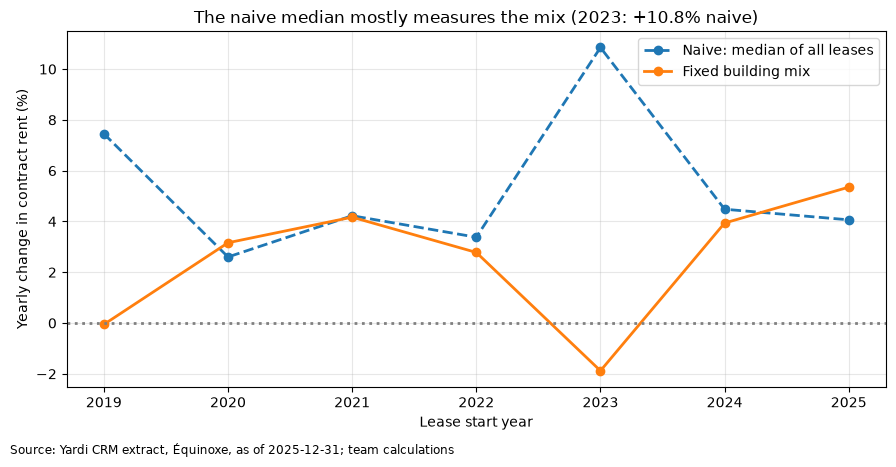

,naive_growth,fixed_building_growth
lease_year,,
2018,NaN,NaN
2019,7.45,-0.06
2020,2.60,3.16
2021,4.23,4.17
2022,3.38,2.78
2023,10.85,-1.88
2024,4.48,3.94
2025,4.06,5.35


In [5]:
building_median = analysis_leases.groupby(["lease_year", "building"]).rent_contract.agg(["median", "size"]).reset_index()
building_median["prev_median"] = building_median.groupby("building")["median"].shift(1)
building_median["prev_year"] = building_median.groupby("building")["lease_year"].shift(1)
comparable = building_median[building_median.prev_year == building_median.lease_year - 1].copy()
comparable["growth"] = comparable["median"] / comparable["prev_median"] - 1
fixed_building_growth = comparable.groupby("lease_year").apply(
    lambda g: np.average(g.growth, weights=g["size"]), include_groups=False)
mix_yearly["fixed_building_growth"] = fixed_building_growth
mix_yearly["naive_growth"] = naive_yearly["naive_growth"]

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(mix_yearly.index, mix_yearly.naive_growth * PCT, "o--", label="Naive: median of all leases")
ax.plot(mix_yearly.index, mix_yearly.fixed_building_growth * PCT, "o-", label="Fixed building mix")
ax.axhline(0, color="grey", linestyle=":")
ax.set_title("The naive median mostly measures the mix (2023: +10.8% naive)")
ax.set_xlabel("Lease start year")
ax.set_ylabel("Yearly change in contract rent (%)")
ax.legend()
add_source(fig)
plt.tight_layout()
plt.show()
(mix_yearly[["naive_growth", "fixed_building_growth"]] * PCT).round(2)

**Bottom line for §3:** the naive 2023 jump comes from Le Carlyle (2023), The Met (2023) and Westpark (2024) joining:
upscale buildings that rent smaller units at a higher price per sq ft. The units rented get *smaller*
while the median goes *up*. With the building mix held fixed, the 2023 jump disappears. This correction is still noisy (e.g. 2019 and 2023
are negative) because the mix *also* changes *inside* each building (which units get re-let).
So a rent increase has to be measured **apartment by apartment** (§4).

In [6]:
naive_yearly.to_parquet(INTERIM_DIR / "naive_yearly.parquet")
mix_yearly.to_parquet(INTERIM_DIR / "mix_yearly.parquet")